**1. Mounting Google Drive in Colab**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd

from scipy.stats import ttest_ind, bootstrap
from statsmodels.stats.multitest import multipletests

**2. STATISTICAL ANALYSIS**

**2.1 Mean ± Std. AND Normal distribution of Hybrid**

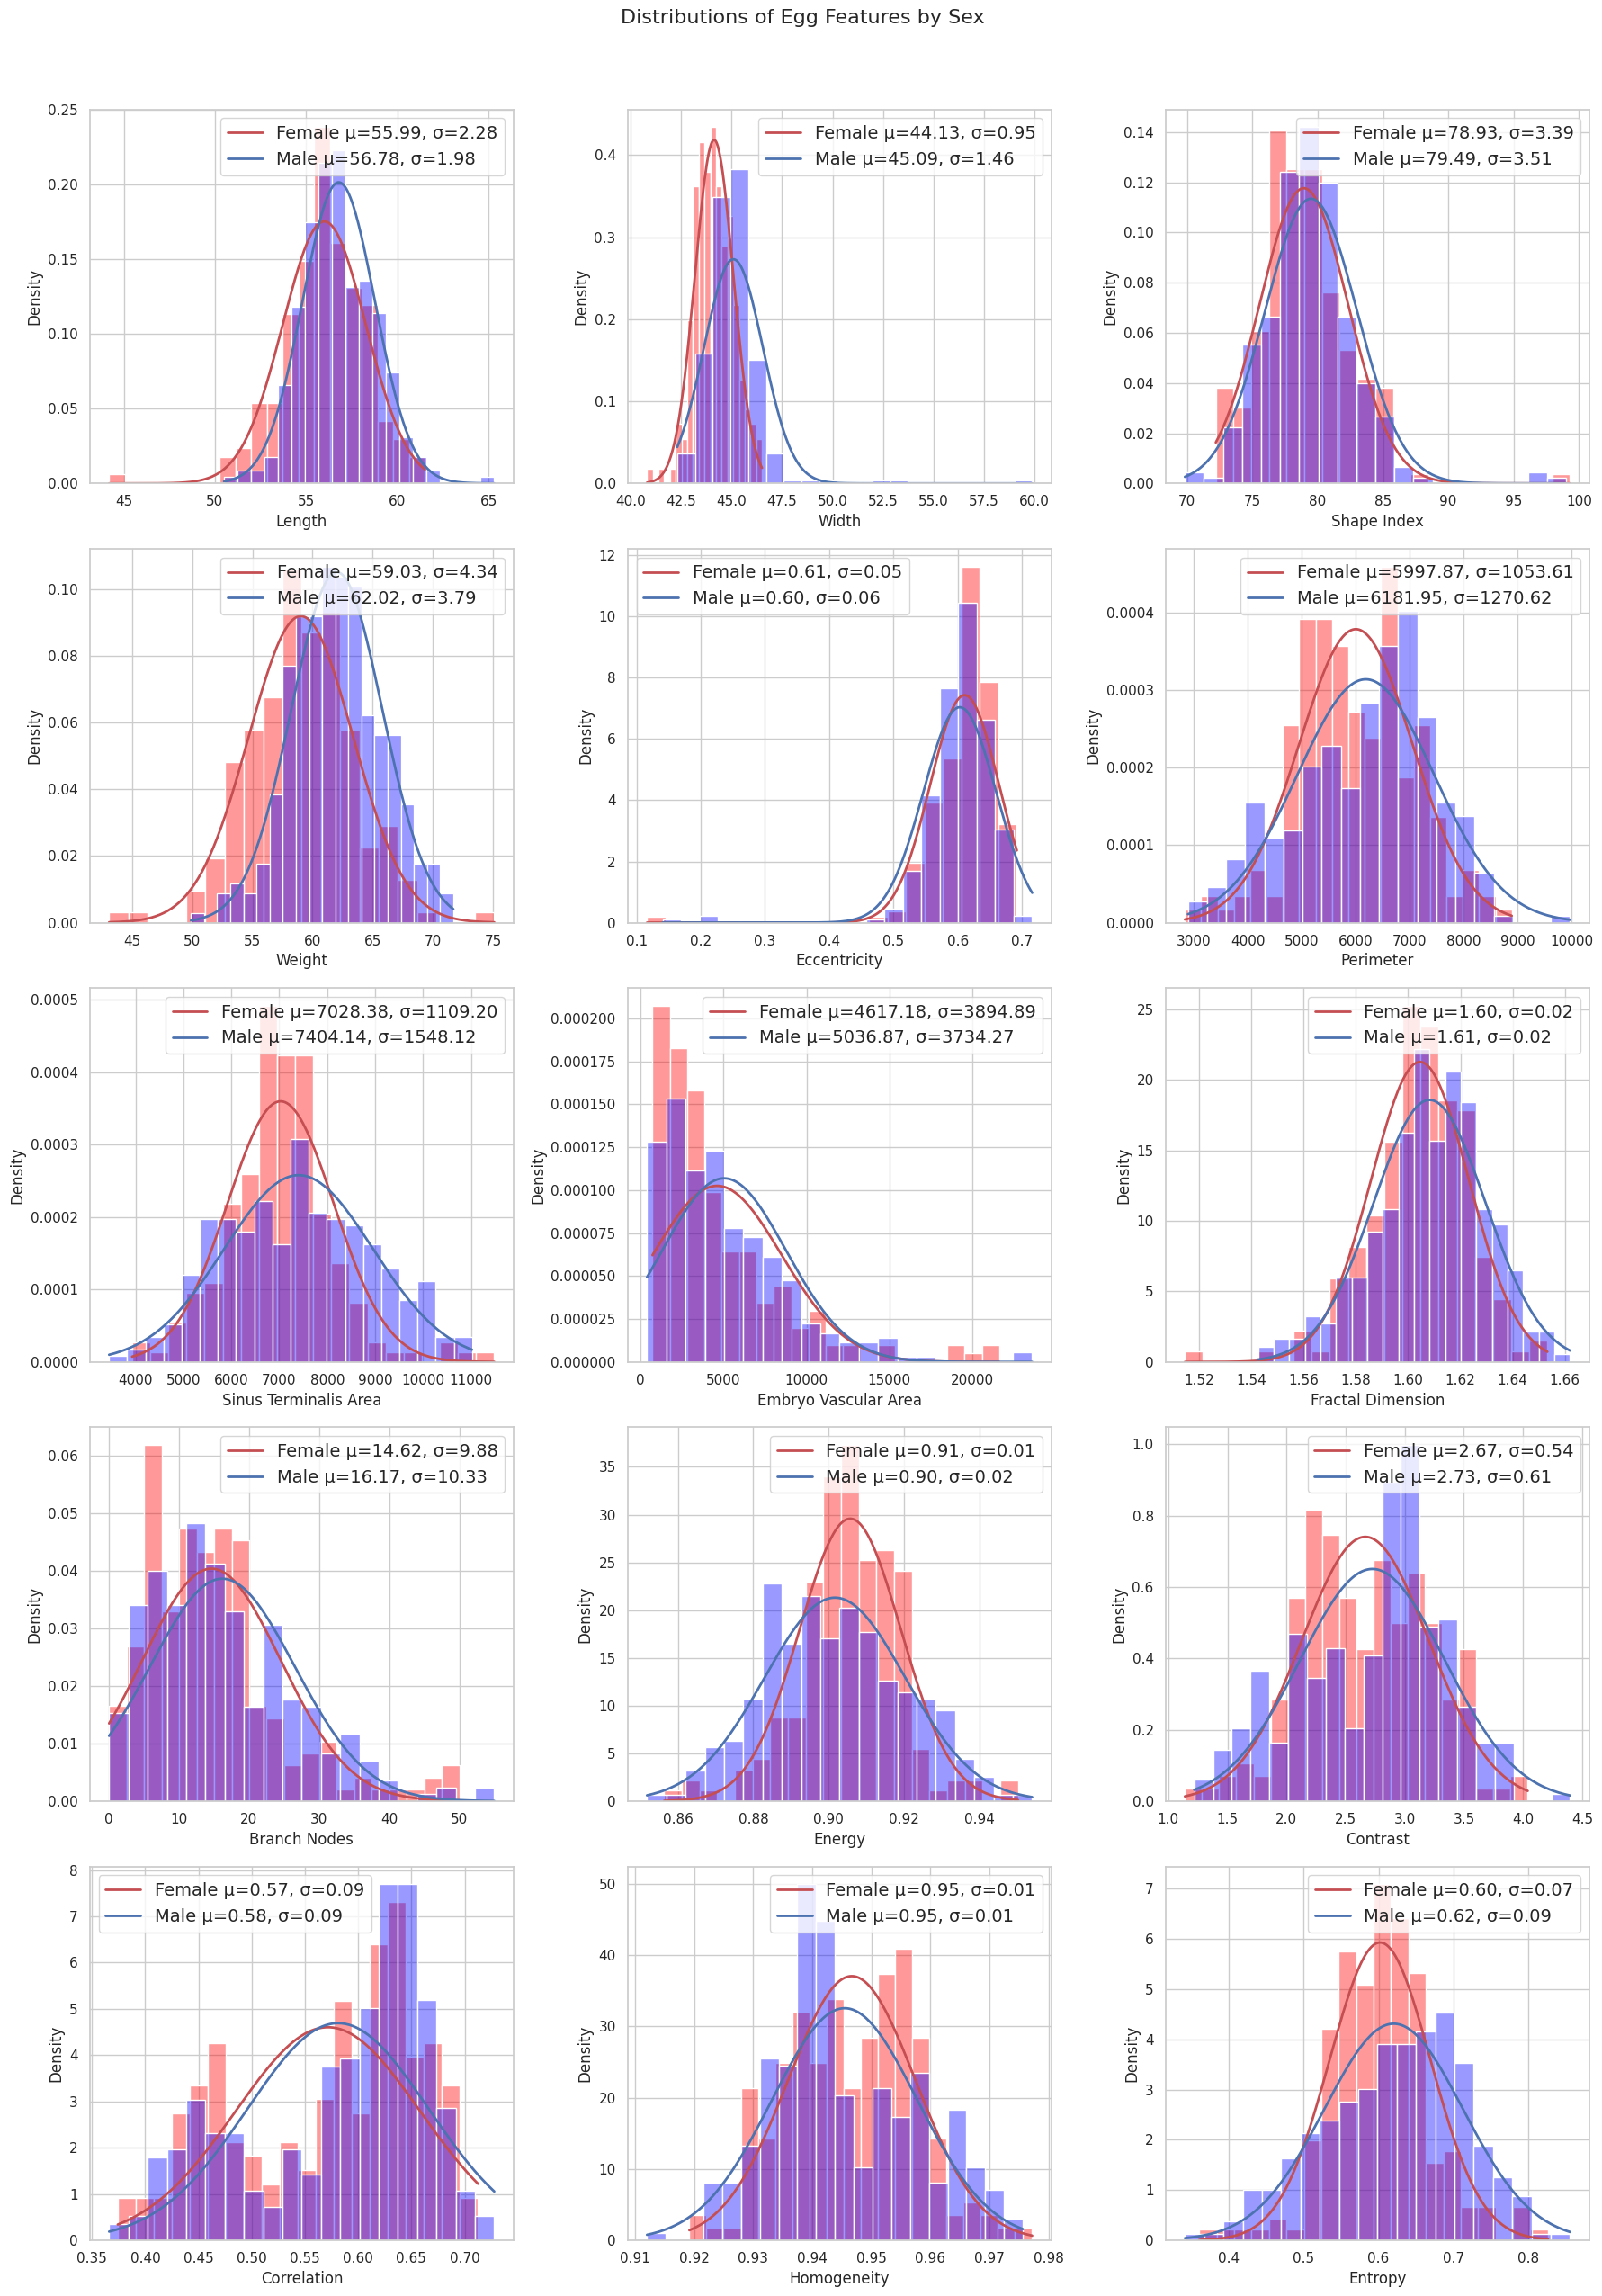

In [ ]:
# STATISTICAL ANALYSIS
# Mean ± Std. AND Normal distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Set input/output paths
base_folder = '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs'

features_folder = os.path.join(
    base_folder,
    'Features'
)

input_path = os.path.join(
    features_folder,
    'Morphological_Embryologic_Vascular_Textural_GLCM.csv'
)

output_path = os.path.join(
    features_folder,
    'Statistical_Analysis.csv'
)

df = pd.read_csv(input_path)

# Mapping Class
df['Class'] = df['Class'].map({'F':'Female', 'M':'Male'})
morph_features = ['Length', 'Width', 'Shape_Index', 'Weight', 'Eccentricity', 'Perimeter', 'Sinus_Terminalis_Area',
                  'Embryo_Vascular_Area', 'Fractal_Dimension', 'Branch_Nodes', 'GLCM_Energy', 'GLCM_Contrast',
                  'GLCM_Correlation', 'GLCM_Homogeneity', 'GLCM_Entropy']
df_morph = df[morph_features + ['Class']]

# Grafik distribusi normal
sns.set(style="whitegrid")

# Tentukan jumlah kolom per baris
n_cols = 3
n_features = len(morph_features)
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(morph_features):
    ax = axes[i]

    # Data Female
    female_data = df_morph[df_morph['Class']=='Female'][feature]
    sns.histplot(female_data, color='red', kde=False, stat='density', bins=20, alpha=0.4, ax=ax)
    mu_f, std_f = female_data.mean(), female_data.std()
    x_f = np.linspace(female_data.min(), female_data.max(), 200)
    ax.plot(x_f, norm.pdf(x_f, mu_f, std_f), 'r-', lw=2, label=f'Female μ={mu_f:.2f}, σ={std_f:.2f}')

    # Data Male
    male_data = df_morph[df_morph['Class']=='Male'][feature]
    sns.histplot(male_data, color='blue', kde=False, stat='density', bins=20, alpha=0.4, ax=ax)
    mu_m, std_m = male_data.mean(), male_data.std()
    x_m = np.linspace(male_data.min(), male_data.max(), 200)
    ax.plot(x_m, norm.pdf(x_m, mu_m, std_m), 'b-', lw=2, label=f'Male μ={mu_m:.2f}, σ={std_m:.2f}')

    # Label grafik
    #ax.set_xlabel(feature.replace('GLCM_', ''))
    ax.set_xlabel(feature.replace('GLCM_', '').replace('_', ' '))
    ax.set_ylabel("Density")
    ax.legend(fontsize=14)

# Hapus axis kosong jika jumlah fitur tidak habis dibagi 3
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distributions of Egg Features by Sex", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**2.2 Statistical Analysis**

In [ ]:
# STATISTICAL ANALYSIS
# Descriptive Statistics + Welch's t-test
# Holm Multiple-Comparison Correction
# Hedges' g* + 95% BCa Bootstrap CI

import os
import numpy as np
import pandas as pd

from scipy.stats import ttest_ind, bootstrap
from statsmodels.stats.multitest import multipletests

# Set input/output paths
base_folder = '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs'

features_folder = os.path.join(base_folder, 'Features')
input_path = os.path.join(
    features_folder,
    'Morphological_Embryologic_Vascular_Textural_GLCM.csv'
)
output_path = os.path.join(features_folder, 'Statistical_Analysis.csv')

# Faeture
features = [
    "Length",
    "Width",
    "Shape_Index",
    "Weight",
    "Eccentricity",
    "Perimeter",
    "Sinus_Terminalis_Area",
    "Embryo_Vascular_Area",
    "Fractal_Dimension",
    "Branch_Nodes",
    "GLCM_Energy",
    "GLCM_Contrast",
    "GLCM_Correlation",
    "GLCM_Homogeneity",
    "GLCM_Entropy"
]

# Load dataset
def load_dataset(path):
    df = pd.read_csv(path)
    df["Class"] = df["Class"].map({
        "F": "Female",
        "M": "Male"
    })
    return df

# Welch derees of freedom
def calculate_welch_df(female, male):
    n_f = len(female)
    n_m = len(male)

    var_f = np.var(female, ddof=1)
    var_m = np.var(male, ddof=1)

    numerator = (
        var_f / n_f +
        var_m / n_m
    ) ** 2

    denominator = (
        (var_f / n_f) ** 2 / (n_f - 1)
        +
        (var_m / n_m) ** 2 / (n_m - 1)
    )
    return numerator / denominator

# HEDGES' g*
# Non-pooled standard deviation
def calculate_hedges_g_star(female, male):
    mean_f = np.mean(female)
    mean_m = np.mean(male)
    sd_f = np.std(female, ddof=1)
    sd_m = np.std(male, ddof=1)

    # Non-pooled standard deviation
    non_pooled_sd = np.sqrt((sd_f**2 + sd_m**2) / 2)

    # Welch degrees of freedom
    df_welch = calculate_welch_df(female, male)

    # Cohen's d*
    d_star = ((mean_m - mean_f) / non_pooled_sd)

    # Small-sample correction
    correction = (1 - 3 / (4 * df_welch - 1))
    return correction * d_star

# 95% BCa BOOTSTRAP CI
def calculate_bootstrap_ci(
    female,
    male,
    n_resamples=5000,
    confidence_level=0.95,
    random_state=42
):
    rng = np.random.default_rng(
        random_state
    )
    result = bootstrap(
        data=(female, male),
        statistic=calculate_hedges_g_star,
        n_resamples=n_resamples,
        confidence_level=confidence_level,
        method="BCa",
        paired=False,
        vectorized=False,
        axis=0,
        rng=rng
    )
    return (
        result.confidence_interval.low,
        result.confidence_interval.high
    )

# STATISTICAL ANALYSIS
def statistical_analysis(
    df,
    features,
    n_resamples=5000,
    confidence_level=0.95,
    random_state=42
):
    female_df = df[df["Class"] == "Female"]
    male_df = df[df["Class"] == "Male"]
    temporary_results = []
    raw_p_values = []

    # Welch's t-test and descriptive statistics
    for feature in features:
        female = (female_df[feature]
            .dropna()
            .to_numpy()
        )

        male = (male_df[feature]
            .dropna()
            .to_numpy()
        )

        # Mean and SD
        female_mean = np.mean(female)
        female_sd = np.std(
            female,
            ddof=1
        )

        male_mean = np.mean(male)
        male_sd = np.std(male, ddof=1)

        # Male - Female
        delta = (male_mean - female_mean)

        # Welch's t-test
        test = ttest_ind(male, female, equal_var=False)
        t_value = test.statistic
        p_value = test.pvalue

        # Welch df
        df_welch = calculate_welch_df(female, male)

        temporary_results.append({
            "Feature": feature,
            "Female_Mean": female_mean,
            "Female_SD": female_sd,
            "Male_Mean": male_mean,
            "Male_SD": male_sd,
            "Delta_Male_minus_Female": delta,
            "t_value": t_value,
            "Welch_df": df_welch,
            "p_value": p_value
        })
        raw_p_values.append(p_value)

    # Holm correction
    _, p_adjusted, _, _ = multipletests(
        raw_p_values,
        alpha=0.05,
        method="holm"
    )

    # Hedges' g* + 95% BCa CI
    results = []
    for i, result in enumerate(temporary_results):
        feature = result["Feature"]
        female = (
            female_df[feature]
            .dropna()
            .to_numpy()
        )
        male = (
            male_df[feature]
            .dropna()
            .to_numpy()
        )

        # Hedges' g*
        hedges_g_star = (
            calculate_hedges_g_star(
                female,
                male
            )
        )

        # 95% BCa CI
        ci_lower, ci_upper = (
            calculate_bootstrap_ci(
                female,
                male,
                n_resamples=n_resamples,
                confidence_level=confidence_level,
                random_state=random_state
            )
        )
        result["p_adjusted_Holm"] = (p_adjusted[i])
        result["Hedges_g_star"] = (hedges_g_star)
        result["CI95_Lower"] = (ci_lower)
        result["CI95_Upper"] = (ci_upper)
        results.append(result)
    return pd.DataFrame(results)

# P-value formatting
def format_p_value(p_value):
    if p_value < 0.001:
        return "<0.001"
    else:
        return f"{p_value:.4f}"

# Create taable
def create_table(results):
    table = pd.DataFrame()
    #table["Feature"] = (results["Feature"])
    table["Feature"] = (results["Feature"].str.replace("GLCM_", "", regex=False).str.replace("_", " ", regex=False))
    table["Female Mean ± SD"] = (
        results["Female_Mean"]
        .round(4)
        .astype(str)
        + " ± "
        + results["Female_SD"]
        .round(4)
        .astype(str)
    )
    table["Male Mean ± SD"] = (
        results["Male_Mean"]
        .round(4)
        .astype(str)
        + " ± "
        + results["Male_SD"]
        .round(4)
        .astype(str)
    )
    table["Δ (Male − Female)"] = (results["Delta_Male_minus_Female"] .round(6))
    table["t-value"] = (results["t_value"] .round(6))
    table["Welch df"] = (results["Welch_df"] .round(6))
    table["p-value"] = (results["p_value"].apply(format_p_value))
    table["Holm-adjusted p-value"] = (results["p_adjusted_Holm"].apply(format_p_value))
    table["Hedges' g* [95% CI]"] = (
        results["Hedges_g_star"]
        .round(3)
        .astype(str)
        + " ["
        + results["CI95_Lower"]
        .round(3)
        .astype(str)
        + ", "
        + results["CI95_Upper"]
        .round(3)
        .astype(str)
        + "]"
    )
    return table

# Main program
df = load_dataset(input_path)
results = statistical_analysis(
    df=df,
    features=features,
    n_resamples=5000,
    confidence_level=0.95,
    random_state=42
)
table = create_table(results)

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", None)

print("\n")
print("DESCRIPTIVE STATISTICS AND STATISTICAL SIGNIFICANCE")
print("-" * 160)
print(table.to_string(index=False))
print("-" * 160)

# Save
table.to_csv(output_path, index=False)



DESCRIPTIVE STATISTICS AND STATISTICAL SIGNIFICANCE
----------------------------------------------------------------------------------------------------------------------------------------------------------------
              Feature      Female Mean ± SD        Male Mean ± SD  Δ (Male − Female)   t-value   Welch df p-value Holm-adjusted p-value     Hedges' g* [95% CI]
               Length      55.9881 ± 2.2752      56.7799 ± 1.9797           0.791791  3.990657 367.985505  <0.001                0.0010     0.371 [0.187, 0.54]
                Width      44.1278 ± 0.9529      45.0851 ± 1.4602           0.957278  8.895461 500.242640  <0.001                <0.001    0.775 [0.591, 0.942]
          Shape Index        78.9349 ± 3.39       79.4879 ± 3.515           0.553010  1.755615 421.218152  0.0799                0.6335     0.16 [-0.03, 0.334]
               Weight      59.0325 ± 4.3366      62.0217 ± 3.7927           2.989209  7.891176 369.483047  <0.001                <0.001    0.732 